In [49]:
import torch
from torch import nn, Tensor
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
import numpy as np
from flow_matching.solver import ODESolver
from torch.utils.data import TensorDataset, DataLoader
import time

import sys
sys.path.append('./Textual-Anomaly-Detection-Framework/Anomaly Detection Framework')
import Modelisation.evaluation as ev
from utils import load_data_inlier, load_data_test
from utils import save_results

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Model

In [2]:
class FlowMatching(nn.Module):
    def __init__(self, source, target, input_dim=64, latent_dim=256, device='cuda', seed=42):
        super().__init__()
        
        self.seed = seed
        self.target = target
        self.source = source
        self.device = device
            
        if self.source == 'target-noised':
            noise = torch.randn(self.target.shape[0], self.target.shape[1])
            self.target_noised = self.target + noise
            
        if self.source == 'point-mean':
            self.point_mean = self.target.mean(dim=0).to(self.device)            
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.expand(x.shape[0], 1)            
        xt = torch.cat([x, t], dim=1)

        return self.net(xt)
    
    def sampling_source(self, n_samples):

        
        if self.source == 'gaussian':
            return torch.randn(n_samples, self.input_dim).to(self.device)
    
        if self.source == 'circle': return Tensor(make_circles(n_samples=n_samples, noise=0.05, factor=0.95)[0]).to(self.device)
    
        if self.source == 'poisson': return Tensor(np.random.poisson(5, (n_samples, self.input_dim))).to(self.device)
    
        if self.source == 'uniform': return Tensor(np.random.uniform(low=self.target.min(), high=self.target.max(), size=(n_samples, self.input_dim))).to(self.device)
    
        if self.source == 'sphere':
            
            z = torch.randn(n_samples, self.input_dim)
            return Tensor(z / z.norm(dim=1, keepdim=True)).to(self.device)
        
        if self.source == 'sphere-noised':
            z = torch.randn(n_samples, self.input_dim)
                   
            z = z / z.norm(dim=1, keepdim=True)
            noise = torch.randn_like(z) * 0.25
            return Tensor(z + noise).to(self.device)
        
        if self.source == 'point-mean':
            # return self.point_mean.repeat(n_samples).reshape(-1,self.input_dim)
            return Tensor(np.array([0, 0]).repeat(n_samples).reshape(-1,self.input_dim)).to(self.device)
            
        
    def interpolation(self, n_samples, x1=None):

        # source sampling
        x0 = self.sampling_source(n_samples)
        # target sampling ( get n_samples examples from the all target dataset )
        # replace --> avec ou sans remise
        if x1 is None : idx = np.random.choice(self.target.shape[0], n_samples, replace=True)
        
        if self.source == 'target-noised':
            noise = torch.randn(x1.shape[0], x1.shape[1]).to(self.device)
            x0 = x1 + noise
        
        if x1 is None : x1 = self.target[idx].to(self.device)

        # sampling the time between 0 ad 1
        t = torch.rand(n_samples, 1).to(self.device)
        # t = torch.rand(n_samples).to(self.device)

        xt = (1 - t) * x0 + t * x1
        ut = x1 - x0
        
        return xt, t, ut

## Trainer

In [3]:
class FlowMatchingTrainer():
    def __init__(self, flow_model,  verbose=True):

        self.flow_model = flow_model
        self.verbose = verbose

    def train(self, dataloader, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam'):
        
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(self.flow_model.parameters(), lr=lr, weight_decay=weight_decay)

        for s in range(n_epochs):

            for data, in dataloader:

                xt, t, ut = self.flow_model.interpolation(data.shape[0], data)
                vt =  self.flow_model(xt, t)

                optimizer.zero_grad()

                loss = loss_fn(vt, ut)
                loss.backward()

                optimizer.step()
            
            if self.verbose and s % (n_epochs // 5) == 0:
                print(f" step {s} -> loss : {loss.item():.5f}")
                
        return self.flow_model

    def forward_flow(self, x_0, solver_type='midpoint', n_steps=10):
            
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target

    def backward_flow(self,x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source
    
    def forward_backward_flow(self, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_inter_target_to_source[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target_recons


    def test(self, X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10):

        if score_type == 'norm':
            x_source_after_backward = self.backward_flow(X_test, solver_type, n_steps)[-1].cpu().detach()
            # scores = ((x_source_after_backward - self.flow_model.target_centroid) ** 2).sum(dim=1)
            scores = (x_source_after_backward ** 2).sum(dim=1)

        if score_type == 'recons':
            x_target_after_forward_backward = self.forward_backward_flow(X_test, solver_type, n_steps)[-1]
            scores = ((torch.norm(x_target_after_forward_backward - X_test, dim=1)** 2)).cpu().detach()
 
        # auc = roc_auc_score(y_test, scores)
        # ap = average_precision_score(y_test, scores)
        # fpr, tpr, thresholds = roc_curve(y_test, scores)
        # idx = np.where(tpr >= 0.95)[0][0]
        # fpr95 = fpr[idx]

        auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)

        print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  

        return auc, fpr95, ap 

## Data

In [4]:
inlier_topic = 'computer'
dataset_name = '20newsgroups'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 6

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

print(data_train)
print(data_test)

X_inlier = Tensor(data_train['sbert_embeddings']).to(device)
X_test =  Tensor(data_test['sbert_embeddings']).to(device)
y_test = np.array(data_test['anomaly_class'])

Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 2576
})
Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 1909
})


## Run

In [5]:
batch_size = 64
X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

input_dim = X_inlier.shape[1]
latent_dim = 256
lr = 1e-5
weight_decay = 1e-5
n_epochs = 1000

target = X_inlier.cpu()
source = 'target-noised'

flow_model = FlowMatching(source, target, input_dim, latent_dim, device).to(device)
optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.MSELoss()

fm_trainer = FlowMatchingTrainer(flow_model, verbose=True)

flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='recons', solver_type='midpoint', n_steps=10)


 step 0 -> loss : 1.01433
 step 200 -> loss : 0.88213
 step 400 -> loss : 0.89774
 step 600 -> loss : 0.82025
 step 800 -> loss : 0.81713
FM --> AUC: 0.8155 | FPR@95: 0.7161 | AP: 0.3811


In [10]:
# x_inter_target_to_source = fm_trainer.backward_flow(X_test)[-1]
# scores = (x_inter_target_to_source ** 2).sum(dim=1)

In [11]:
# x_inter_target_to_source_inlier = x_inter_target_to_source[:, y_test == 0, :]
# x_inter_target_to_source_inlier.shape
# x_inter_target_to_source_anomaly = x_inter_target_to_source[:, y_test == 1, :]
# x_inter_target_to_source_anomaly.shape

## Toy Example

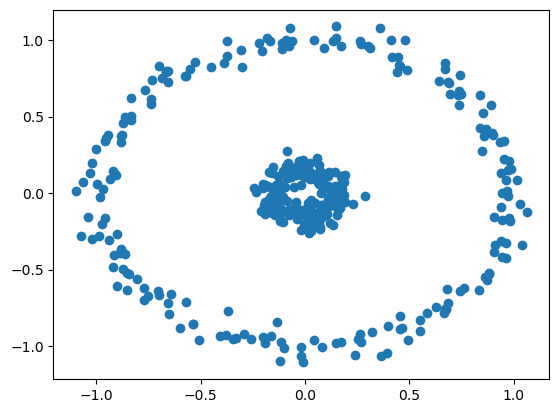

In [185]:
# a = np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])
a = np.concatenate([make_circles(400, noise=0.05, factor=0.15)[0] , torch.randn(0, 2)])
plt.scatter(a[:,0], a[:,1])

In [186]:
batch_size = 256
# X_train = TensorDataset(Tensor(np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])).to(device))
# X_train = TensorDataset(Tensor(make_moons(256, noise=0.05)[0]).to(device))
X_train = Tensor(make_circles(noise=0.05, factor=0.15)[0]).to(device)
# X_train = Tensor(np.array([0, 0]).repeat(300).reshape(-1,2)).to(device)
# X_train = Tensor(torch.randn(300, 2)).to(device)
X_inlier_dl = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)

input_dim = 2
latent_dim = 64
lr = 1e-2
weight_decay = 0
n_epochs = 10000

target = X_train.cpu()
source = 'gaussian'

flow_model = FlowMatching(source, target, input_dim, latent_dim, device).to(device)
optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.MSELoss()

fm_trainer = FlowMatchingTrainer(flow_model, verbose=True)

flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

 step 0 -> loss : 1.59012
 step 2000 -> loss : 0.85558
 step 4000 -> loss : 0.87515
 step 6000 -> loss : 0.74925
 step 8000 -> loss : 0.60948


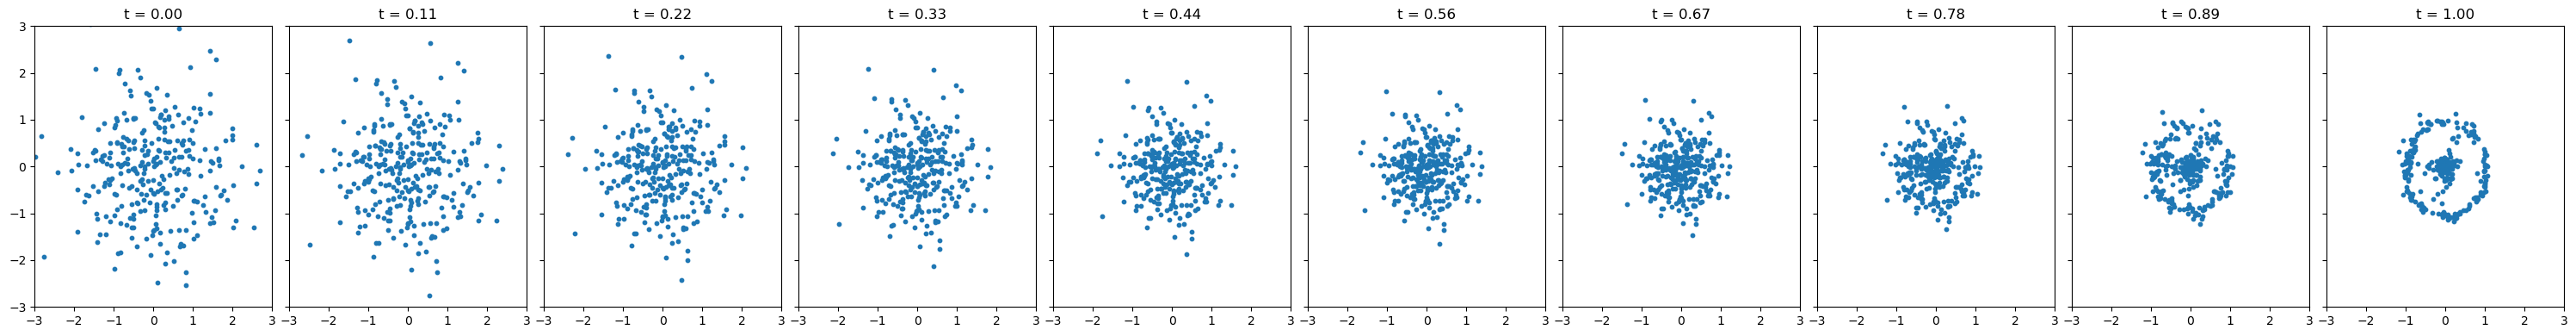

In [187]:
# x_0 = torch.randn(300, 2).to(device)
# x_0 = Tensor(np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])).to(device)
# x_0 = Tensor(np.concatenate([make_circles(n_samples=300, noise=0.05, factor=0.95)[0] , torch.randn(30, 2)])).to(device)
x_0 = flow_model_trained.sampling_source(300)
# x_0 = Tensor([0]).to(device)
x_inter_source_to_target = fm_trainer.forward_flow(x_0)

n_steps = x_inter_source_to_target.shape[0]

fig, axes = plt.subplots(1, n_steps, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps)

for i in range(n_steps):
    axes[i].scatter(
        x_inter_source_to_target[i, :, 0].cpu(),
        x_inter_source_to_target[i, :, 1].cpu(),
        s=10
    )
    axes[i].set_title(f't = {time_steps[i]:.2f}')
    axes[i].set_xlim(-3.0, 3.0)
    axes[i].set_ylim(-3.0, 3.0)

plt.tight_layout()
plt.show()


In [188]:
# x_1 = Tensor(make_moons(300, noise=0.05)[0]).to(device)
x_1 = Tensor(make_circles(n_samples=300, noise=0.05, factor=0.15)[0]).to(device)
# x_1 = Tensor(np.array([0, 0]).repeat(300).reshape(-1,2)).to(device)
# x_1 = Tensor(torch.randn(300, 2)).to(device)
# x_1 = Tensor(np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])).to(device)
x_inter_target_to_source = fm_trainer.backward_flow(x_1)

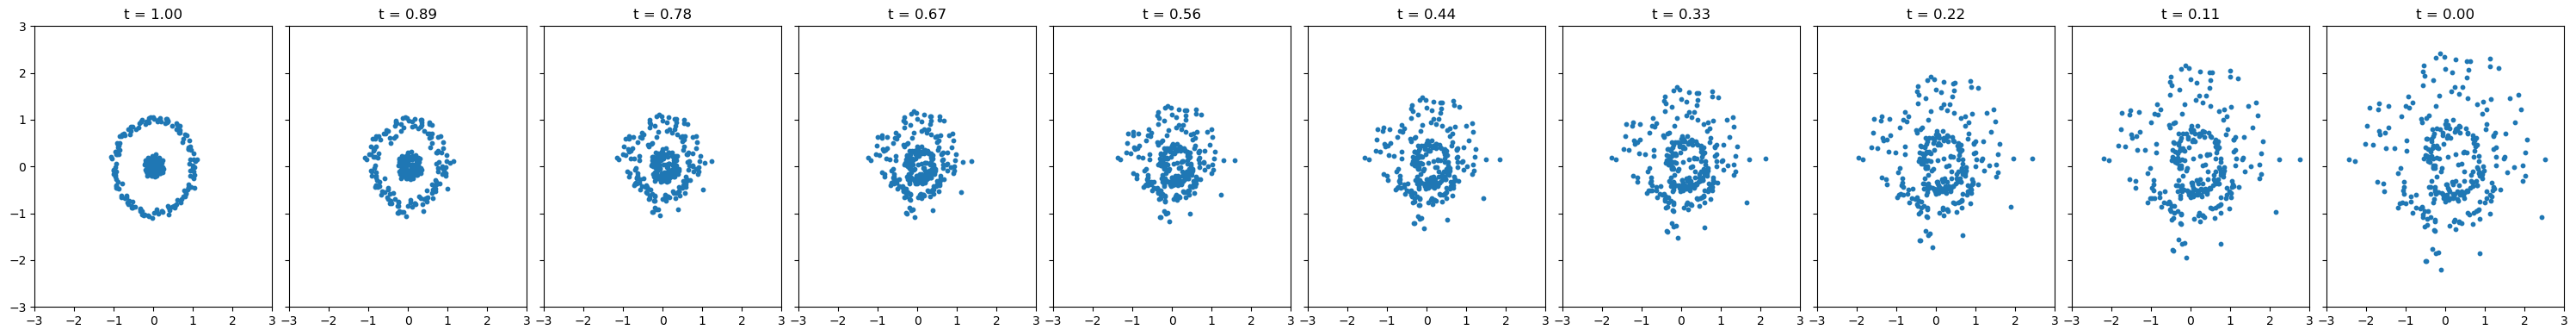

In [189]:
n_steps = x_inter_target_to_source.shape[0]

fig, axes = plt.subplots(1, n_steps, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(1., 0.0, n_steps)

for i in range(n_steps):
    axes[i].scatter(
        x_inter_target_to_source[i, :, 0].cpu(),
        x_inter_target_to_source[i, :, 1].cpu(),
        s=10
    )
    axes[i].set_title(f't = {time_steps[i]:.2f}')
    axes[i].set_xlim(-3.0, 3.0)
    axes[i].set_ylim(-3.0, 3.0)

plt.tight_layout()
plt.show()


In [190]:
@torch.no_grad()
def get_point_velocity(model, traj_point, device):
    
    velocities = []

    for i in range(traj_point.shape[0]):
        x = traj_point[i].unsqueeze(0).to(device)  
        t = torch.tensor([[i / (traj_point.shape[0] - 1)]], device=device)
        v = model(x, t) 
        velocities.append(v.cpu().squeeze(0))

    return torch.stack(velocities)

In [191]:
point_idx = 18
traj_point = x_inter_source_to_target[:, point_idx, :]

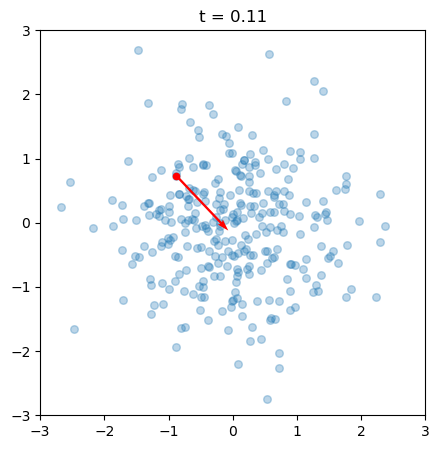

In [192]:
t_idx = 1
vel_point = get_point_velocity(flow_model_trained, traj_point, device)

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    x_inter_source_to_target[t_idx, :, 0].cpu(),
    x_inter_source_to_target[t_idx, :, 1].cpu(),
    s=30,
    alpha=0.3
)

x, y = traj_point[t_idx].cpu()
vx, vy = vel_point[t_idx].cpu()

ax.scatter(x, y, c="red", s=20, zorder=3)

ax.quiver(
    x, y,
    vx, vy,
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color="red",
    width=0.006,
    zorder=4
)

ax.set_title(f"t = {t_idx / 9:.2f}")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")

plt.show()

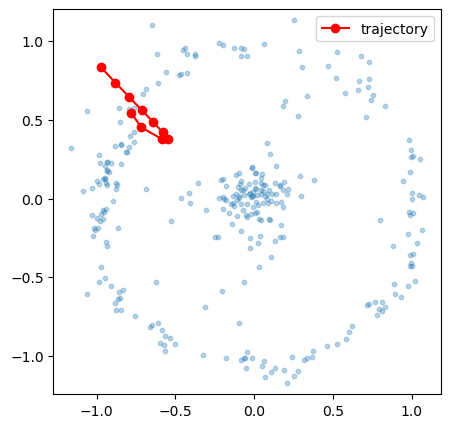

In [193]:
plt.figure(figsize=(5, 5))

plt.scatter(
    x_inter_source_to_target[-1, :, 0].cpu(),
    x_inter_source_to_target[-1, :, 1].cpu(),
    s=10, alpha=0.3
)

plt.plot(
    traj_point[:, 0].cpu(),
    traj_point[:, 1].cpu(),
    "-o",
    c="red",
    label="trajectory"
)

plt.legend()
plt.axis("equal")
plt.show()

## AEFM

Two strategies of training can be done : 
- Train separately the **Flow Encoder** and the **Flow Decoder** and then train them together with a **reconstruction loss**
- Train the **Flow Encoder** and the **Flow Decoder** jointly with a global loss composed of **Flow Encoder FM Loss,** **Flow Decoder FM Loss** and the **reconstruction loss**

### Separated Training

In [175]:
class FlowMatching(nn.Module):
    def __init__(self, source, target, input_dim=64, latent_dim=256, device='cuda', seed=42):
        super().__init__()
        
        self.seed = seed
        self.target = target
        self.source = source
        self.device = device
                         
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.expand(x.shape[0], 1)            
        xt = torch.cat([x, t], dim=1)

        return self.net(xt)
    
    def sampling(self, n_samples):

        return torch.randn(n_samples, self.input_dim).to(self.device)

    def interpolation(self, samples, phase='encoder'):

        n_samples = samples.shape[0]

        if phase == 'encoder':    
            x0 = samples
            x1 = self.sampling(n_samples)
        
        if phase == 'decoder':
            x0 = self.sampling(n_samples)
            x1 = samples

        # sampling the time between 0 ad 1
        t = torch.rand(n_samples, 1).to(self.device)
        # t = torch.rand(n_samples).to(self.device)

        xt = (1 - t) * x0 + t * x1
        ut = x1 - x0
        
        return xt, t, ut
    

class FlowMatchingAETrainer():
    def __init__(self, flow_model, type='encoder',  verbose=True):

        self.flow_model = flow_model
        self.type = type
        self.verbose = verbose

    def train(self, dataloader, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam'):
        
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(self.flow_model.parameters(), lr=lr, weight_decay=weight_decay)

        for s in range(n_epochs):

            for data, in dataloader:

                xt, t, ut = self.flow_model.interpolation(data, self.type)
                vt =  self.flow_model(xt, t)

                optimizer.zero_grad()

                loss = loss_fn(vt, ut)
                loss.backward()

                optimizer.step()
            
            if self.verbose and s % (n_epochs // 5) == 0:
                print(f" step {s} -> loss : {loss.item():.5f}")
                
        return self.flow_model

    def forward_flow(self, x_0, solver_type='midpoint', n_steps=10):
            
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target

    def backward_flow(self,x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source
    
    def backward_forward_flow(self, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_inter_target_to_source[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target_recons
    
    def forward_backward_flow(self, x_0, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)
        
        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_inter_source_to_target_recons[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source


    def test(self, X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10):

        if score_type == 'norm':
            x_source_after_backward = self.backward_flow(X_test, solver_type, n_steps)[-1].cpu().detach()
            # scores = ((x_source_after_backward - self.flow_model.target_centroid) ** 2).sum(dim=1)
            scores = (x_source_after_backward ** 2).sum(dim=1)

        if score_type == 'recons':
            x_target_after_forward_backward = self.forward_backward_flow(X_test, solver_type, n_steps)[-1]
            scores = ((torch.norm(x_target_after_forward_backward - X_test, dim=1)** 2)).cpu().detach()
 
        auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)

        print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  

        return auc, fpr95, ap 

In [179]:
inlier_topic = 'computer'
dataset_name = '20newsgroups'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
X_inlier = Tensor(data_train['sbert_embeddings']).to(device)

for n_run in range(1,11):
    # n_run = 3

    data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
    X_test =  Tensor(data_test['sbert_embeddings']).to(device)
    y_test = np.array(data_test['anomaly_class'])

    list_auc_fm = []
    list_fpr_fm = []
    list_ap_fm = []

    input_dim = X_inlier.shape[1]
    latent_dim = 256

    ###########################
    ######### ENCODER #########
    ###########################
    source = X_inlier.cpu()
    target = 'gaussian'
    flow_encoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

    fmae_encoder_trainer = FlowMatchingAETrainer(flow_encoder, 'encoder')

    batch_size = 64
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)
    lr = 1e-4
    weight_decay = 1e-5
    n_epochs = 50
    loss_fn = nn.MSELoss()

    _ = fmae_encoder_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

    ###########################
    ######### DECODER #########
    ###########################

    source = 'gaussian'
    target = X_inlier.cpu() 
    flow_decoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

    fmae_decoder_trainer = FlowMatchingAETrainer(flow_decoder, 'decoder')

    batch_size = 64
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)
    lr = 1e-4
    weight_decay = 1e-5
    n_epochs = 50
    loss_fn = nn.MSELoss()

    _ = fmae_decoder_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')


    ###### INFERENCE ######
    x_0 = X_test
    sbert_to_gaussian = fmae_encoder_trainer.forward_flow(x_0)[-1]
    gaussian_to_sbert = fmae_decoder_trainer.forward_flow(sbert_to_gaussian)[-1]

    scores = ((torch.norm(gaussian_to_sbert - X_test, dim=1)** 2)).cpu().detach()

    auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=True)
    list_ap_fm.append(ap)
    list_auc_fm.append(auc)
    list_fpr_fm.append(fpr95)


 step 0 -> loss : 0.98474
 step 10 -> loss : 0.94927
 step 20 -> loss : 0.88411
 step 30 -> loss : 0.86987
 step 40 -> loss : 0.84276
 step 0 -> loss : 1.01650
 step 10 -> loss : 0.95333
 step 20 -> loss : 0.86714
 step 30 -> loss : 0.83641
 step 40 -> loss : 0.85318
AUC:        0.8937
Avg Precision: 0.5823
FPR@95:     0.4875
 step 0 -> loss : 0.99978
 step 10 -> loss : 0.94114
 step 20 -> loss : 0.91333
 step 30 -> loss : 0.86408
 step 40 -> loss : 0.85268
 step 0 -> loss : 0.99506
 step 10 -> loss : 0.94615
 step 20 -> loss : 0.89630
 step 30 -> loss : 0.86330
 step 40 -> loss : 0.85293
AUC:        0.8024
Avg Precision: 0.3429
FPR@95:     0.7126
 step 0 -> loss : 1.00878
 step 10 -> loss : 0.93609
 step 20 -> loss : 0.90845
 step 30 -> loss : 0.85653
 step 40 -> loss : 0.85496
 step 0 -> loss : 1.00853
 step 10 -> loss : 0.93796
 step 20 -> loss : 0.88688
 step 30 -> loss : 0.89011
 step 40 -> loss : 0.84605
AUC:        0.8872
Avg Precision: 0.5065
FPR@95:     0.4462
 step 0 -> loss 

In [180]:
np.mean(list_auc_fm)

0.8889041976669422

### Jointly Training

In [154]:
class FlowMatching(nn.Module):
    def __init__(self, source, target, input_dim=64, latent_dim=256, device='cuda', seed=42):
        super().__init__()
        
        self.seed = seed
        self.target = target
        self.source = source
        self.device = device
                         
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.expand(x.shape[0], 1)            
        xt = torch.cat([x, t], dim=1)

        return self.net(xt)
    
    def sampling(self, n_samples):

        return torch.randn(n_samples, self.input_dim).to(self.device)

    def interpolation(self, samples, phase='encoder', t=None):

        n_samples = samples.shape[0]

        if phase == 'encoder':    
            x0 = samples
            x1 = self.sampling(n_samples)
        
        if phase == 'decoder':
            x0 = self.sampling(n_samples)
            x1 = samples

        # sampling the time between 0 ad 1
        if t is None:
            t = torch.rand(n_samples, 1).to(self.device)
        # t = torch.rand(n_samples).to(self.device)

        xt = (1 - t) * x0 + t * x1
        ut = x1 - x0
        
        return xt, t, ut
    

class FlowMatchingAETrainer():
    def __init__(self, flow_encoder, flow_decoder, lambda_1, lambda_2, lambda_3, device=device, verbose=True):

        self.flow_encoder = flow_encoder
        self.flow_decoder = flow_decoder
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.lambda_3 = lambda_3
        self.device = device
        self.verbose = verbose

    def train(self, dataloader, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam'):
        
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(list(self.flow_encoder.parameters()) + list(self.flow_decoder.parameters()), lr=lr, weight_decay=weight_decay)

        for s in range(n_epochs):

            for data, in dataloader:

                t = torch.rand(data.shape[0], 1).to(self.device)

                # Flow Encoder Loss
                xt_encoder, _, ut_encoder = self.flow_encoder.interpolation(data, 'encoder', t)
                vt_encoder =  self.flow_encoder(xt_encoder, t)

                optimizer.zero_grad()
                loss_encoder = loss_fn(vt_encoder, ut_encoder)
                
                # Flow Decoder Loss
                xt_decoder, _, ut_decoder = self.flow_decoder.interpolation(data, 'decoder', t)
                vt_decoder =  self.flow_decoder(xt_decoder, t)

                optimizer.zero_grad()
                loss_decoder = loss_fn(vt_decoder, ut_decoder)

                # Reconstruction Loss
                data_to_gaussian = self.forward_flow(self.flow_encoder, data)[-1]
                data_hat = self.forward_flow(self.flow_decoder, data_to_gaussian)[-1]

                loss_recons = loss_fn(data, data_hat)     

                # Loss           
                loss = self.lambda_1*loss_encoder + self.lambda_2*loss_decoder + self.lambda_3*loss_recons                
                loss.backward()

                optimizer.step()
            
            if self.verbose and s % (n_epochs // 3) == 0:
                print(
                    f"step {s}\n"
                    f"  ├─ loss_encoder     : {loss_encoder.item():.5f}\n"
                    f"  ├─ loss_decoder     : {loss_decoder.item():.5f}\n"
                    f"  ├─ loss_reconstruction     : {loss_recons.item():.5f}\n"
                    f"  └─ loss_total : {loss.item():.5f}"
                )

    def forward_flow(self, flow_model, x_0, solver_type='midpoint', n_steps=10):
            
        solver = ODESolver(velocity_model=flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target

    def backward_flow(self, flow_model, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source
    
    def backward_forward_flow(self, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_inter_target_to_source[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target_recons
    
    def forward_backward_flow(self, x_0, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)
        
        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_inter_source_to_target_recons[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source


    def test(self, X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10):

        if score_type == 'norm':
            x_source_after_backward = self.backward_flow(X_test, solver_type, n_steps)[-1].cpu().detach()
            # scores = ((x_source_after_backward - self.flow_model.target_centroid) ** 2).sum(dim=1)
            scores = (x_source_after_backward ** 2).sum(dim=1)

        if score_type == 'recons':
            x_target_after_forward_backward = self.forward_backward_flow(X_test, solver_type, n_steps)[-1]
            scores = ((torch.norm(x_target_after_forward_backward - X_test, dim=1)** 2)).cpu().detach()
 
        auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)

        print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  

        return auc, fpr95, ap 

In [157]:
inlier_topic = 'Sci-Tech'
dataset_name = 'agnews'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
# n_run = 1
data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
X_inlier = Tensor(data_train['sbert_embeddings']).to(device)

list_auc_fm = []
list_fpr_fm = []
list_ap_fm = []
list_time_fm = []

for n_run in range(1, 11):

    data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
    X_test =  Tensor(data_test['sbert_embeddings']).to(device)
    y_test = np.array(data_test['anomaly_class'])

    input_dim = X_inlier.shape[1]
    latent_dim = 128

    source = X_inlier.cpu()
    target = 'gaussian'
    flow_encoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

    source = 'gaussian'
    target = X_inlier.cpu()
    flow_decoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

    lambda_1 = 10.
    lambda_2 = 10.
    lambda_3 = 1.

    fmae_trainer = FlowMatchingAETrainer(flow_encoder, flow_decoder, lambda_1, lambda_2, lambda_3,  verbose=False)

    batch_size = 128
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)
    lr = 1e-4
    weight_decay = 0
    n_epochs = 30
    loss_fn = nn.MSELoss()

    tac = time.time()
    fmae_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs)
    tic = time.time()

    list_time_fm.append((tic-tac))

    data_to_gaussian = fmae_trainer.forward_flow(fmae_trainer.flow_encoder, X_test)[-1]
    X_test_hat = fmae_trainer.forward_flow(fmae_trainer.flow_decoder, data_to_gaussian)[-1]

    scores = ((torch.norm(X_test_hat - X_test, dim=1)** 2)).cpu().detach()
    auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)
    print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}", end="\n\n")  

    list_auc_fm.append(auc)
    list_ap_fm.append(ap)
    list_fpr_fm.append(fpr95)

FM --> AUC: 0.7711 | FPR@95: 0.7637 | AP: 0.2691

FM --> AUC: 0.7758 | FPR@95: 0.6374 | AP: 0.2848

FM --> AUC: 0.8118 | FPR@95: 0.6819 | AP: 0.3887

FM --> AUC: 0.7734 | FPR@95: 0.7263 | AP: 0.2996

FM --> AUC: 0.7920 | FPR@95: 0.6643 | AP: 0.2968

FM --> AUC: 0.7927 | FPR@95: 0.7901 | AP: 0.3598

FM --> AUC: 0.7707 | FPR@95: 0.7673 | AP: 0.3403

FM --> AUC: 0.7990 | FPR@95: 0.6936 | AP: 0.3815

FM --> AUC: 0.8232 | FPR@95: 0.6076 | AP: 0.3260

FM --> AUC: 0.7782 | FPR@95: 0.6725 | AP: 0.2597



In [158]:
save_results(
                dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb='sentence-bert' ,ad_model="flow-matching-AE",
                auc_mean=np.mean(list_auc_fm), ap_mean=np.mean(list_ap_fm),fpr_mean=np.mean(list_fpr_fm),
                auc_std = np.std(list_auc_fm),ap_std =  np.std(list_ap_fm),fpr_std = np.std(list_fpr_fm),
                train_time = np.mean(list_time_fm), nu=0.0, overwrite='naive'
                )

Nouveaux résultats ajoutés pour (agnews, Sci-Tech, sentence-bert, flow-matching-AE, nu=0.0).


In [116]:
inlier_topic = 'World'
dataset_name = 'agnews'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 2
data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
X_inlier = Tensor(data_train['sbert_embeddings']).to(device)

data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
X_test =  Tensor(data_test['sbert_embeddings']).to(device)
y_test = np.array(data_test['anomaly_class'])

In [119]:
input_dim = X_inlier.shape[1]
latent_dim = 128

source = X_inlier.cpu()
target = 'gaussian'
flow_encoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

source = 'gaussian'
target = X_inlier.cpu()
flow_decoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

lambda_1 = 10.
lambda_2 = 10.
lambda_3 = 1.

fmae_trainer = FlowMatchingAETrainer(flow_encoder, flow_decoder, lambda_1, lambda_2, lambda_3,  verbose=True)

batch_size = 128
X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)
lr = 1e-4
weight_decay = 1e-4
n_epochs = 50
loss_fn = nn.MSELoss()

tac = time.time()
fmae_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs)
tic = time.time()

list_time_fm.append((tic-tac))

data_to_gaussian = fmae_trainer.forward_flow(fmae_trainer.flow_encoder, X_test)[-1]
X_test_hat = fmae_trainer.forward_flow(fmae_trainer.flow_decoder, data_to_gaussian)[-1]

scores = ((torch.norm(X_test_hat - X_test, dim=1)** 2)).cpu().detach()
auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)
print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}", end="\n\n")  

step 0
  ├─ loss_encoder     : 0.98540
  ├─ loss_decoder     : 0.99919
  ├─ loss_reconstruction     : 0.00127
  └─ loss_total : 19.84713
step 16
  ├─ loss_encoder     : 0.88077
  ├─ loss_decoder     : 0.88979
  ├─ loss_reconstruction     : 0.03102
  └─ loss_total : 17.73659
step 32
  ├─ loss_encoder     : 0.88448
  ├─ loss_decoder     : 0.88475
  ├─ loss_reconstruction     : 0.03386
  └─ loss_total : 17.72617
step 48
  ├─ loss_encoder     : 0.87437
  ├─ loss_decoder     : 0.88007
  ├─ loss_reconstruction     : 0.03155
  └─ loss_total : 17.57588
FM --> AUC: 0.8552 | FPR@95: 0.5099 | AP: 0.4056



## In the neighborhood

In [194]:
class FlowMatching(nn.Module):
    def __init__(self, source, target, input_dim=64, latent_dim=256, device='cuda', seed=42):
        super().__init__()
        
        self.seed = seed

        self.target = target
        self.source = source
        self.centroid = self.source.mean(dim=0)
        self.cov = 0.01 * np.eye(self.source.shape[1])

        self.device = device
                         
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.expand(x.shape[0], 1)            
        xt = torch.cat([x, t], dim=1)

        return self.net(xt)
    
    def sampling(self, n_samples):

        return Tensor(np.random.multivariate_normal(self.centroid, self.cov, n_samples)).to(self.device)

    def interpolation(self, samples):

        n_samples = samples.shape[0]

        x0 = samples
        x1 = self.sampling(n_samples)

        # sampling the time between 0 ad 1
        t = torch.rand(n_samples, 1).to(self.device)
        
        xt = (1 - t) * x0 + t * x1
        ut = x1 - x0
        
        return xt, t, ut

In [195]:
class FlowMatchingTrainer():
    def __init__(self, flow_model,  verbose=True):

        self.flow_model = flow_model
        self.verbose = verbose

    def train(self, dataloader, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam'):
        
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(self.flow_model.parameters(), lr=lr, weight_decay=weight_decay)

        for s in range(n_epochs):

            for data, in dataloader:

                xt, t, ut = self.flow_model.interpolation(data)
                vt =  self.flow_model(xt, t)

                optimizer.zero_grad()

                loss = loss_fn(vt, ut)
                loss.backward()

                optimizer.step()
            
            if self.verbose and s % (n_epochs // 5) == 0:
                print(f" step {s} -> loss : {loss.item():.5f}")
                
        return self.flow_model

    def forward_flow(self, x_0, solver_type='midpoint', n_steps=10):
            
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target

    def backward_flow(self,x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source
    
    def forward_backward_flow(self, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_inter_target_to_source[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target_recons


    def test(self, X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10):

        if score_type == 'norm':
            x_source_after_backward = self.forward_flow(X_test, solver_type, n_steps)[-1].cpu().detach()
            scores = ((x_source_after_backward - self.flow_model.centroid) ** 2).sum(dim=1)
            # scores = (x_source_after_backward ** 2).sum(dim=1)

        if score_type == 'recons':
            x_target_after_forward_backward = self.forward_backward_flow(X_test, solver_type, n_steps)[-1]
            scores = ((torch.norm(x_target_after_forward_backward - X_test, dim=1)** 2)).cpu().detach()
 
        # auc = roc_auc_score(y_test, scores)
        # ap = average_precision_score(y_test, scores)
        # fpr, tpr, thresholds = roc_curve(y_test, scores)
        # idx = np.where(tpr >= 0.95)[0][0]
        # fpr95 = fpr[idx]

        auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)

        print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  

        return auc, fpr95, ap 

In [200]:
inlier_topic = 'science'
dataset_name = '20newsgroups'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
# n_run = 6

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
X_inlier = Tensor(data_train['sbert_embeddings']).to(device)

list_auc_fm = []
list_fpr_fm = []
list_ap_fm = []
list_time_fm = []

for n_run in range(1, 11):

    data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
    X_test =  Tensor(data_test['sbert_embeddings']).to(device)
    y_test = np.array(data_test['anomaly_class'])

    batch_size = 64
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

    input_dim = X_inlier.shape[1]
    latent_dim = 256
    lr = 1e-3
    weight_decay = 1e-4
    n_epochs = 20

    source = X_inlier.cpu()
    target = 'centroid-neigh'

    flow_model = FlowMatching(source, target, input_dim, latent_dim, device).to(device)
    optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    fm_trainer = FlowMatchingTrainer(flow_model, verbose=False)

    tac = time.time()
    flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')
    tic = time.time()

    auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10)

    list_auc_fm.append(auc)
    list_ap_fm.append(ap)
    list_fpr_fm.append(fpr95)
    list_time_fm.append((tic-tac))

FM --> AUC: 0.6853 | FPR@95: 0.7341 | AP: 0.1792
FM --> AUC: 0.7147 | FPR@95: 0.6779 | AP: 0.1841
FM --> AUC: 0.7200 | FPR@95: 0.7531 | AP: 0.1986
FM --> AUC: 0.7156 | FPR@95: 0.6523 | AP: 0.1943
FM --> AUC: 0.7221 | FPR@95: 0.7188 | AP: 0.2112
FM --> AUC: 0.6834 | FPR@95: 0.6991 | AP: 0.1633
FM --> AUC: 0.6789 | FPR@95: 0.7999 | AP: 0.1913
FM --> AUC: 0.7019 | FPR@95: 0.7253 | AP: 0.1686
FM --> AUC: 0.7114 | FPR@95: 0.7743 | AP: 0.1977
FM --> AUC: 0.7305 | FPR@95: 0.6961 | AP: 0.2077


In [203]:
save_results(
                dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb='sentence-bert' ,ad_model="flow-matching-CN",
                auc_mean=np.mean(list_auc_fm), ap_mean=np.mean(list_ap_fm),fpr_mean=np.mean(list_fpr_fm),
                auc_std = np.std(list_auc_fm),ap_std =  np.std(list_ap_fm),fpr_std = np.std(list_fpr_fm),
                train_time = np.mean(list_time_fm), nu=0.0, overwrite='naive'
                )

Résultats mis à jour pour (20newsgroups, science, sentence-bert, flow-matching-CN, nu=0.0).


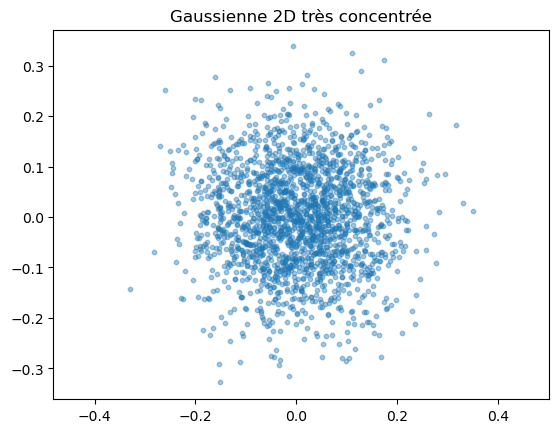

In [180]:
mean = np.array([0.0, 0.0])
cov = 0.01 * np.eye(2)

x = np.random.multivariate_normal(mean, cov, 2000)

plt.figure()
plt.scatter(x[:, 0], x[:, 1], alpha=0.4, s=10)
plt.axis("equal")
plt.title("Gaussienne 2D très concentrée")
plt.show()
